# Spectroscopy of molecules

MEHDI AYOUZ LGPM CENTRALESUPELEC
[mehdi.ayouz@centralesupelec.fr](mehdi.ayouz@centralesupelec.fr)

VIATCHESLAV KOKOOULINE UNIVERSITY OF CENTRAL FLORIDA 
[slavako@ucf.edu](slavako@ucf.edu)

## Preliminaries

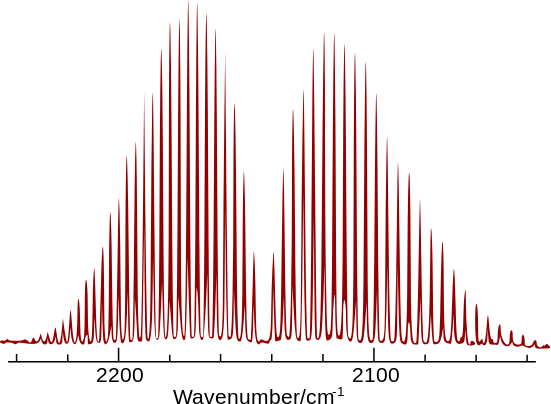

figure of CO

BO in another module

reduced mass

$\Psi_{nvjm}\left(\left\{\tilde{r}_e\right\},\vec{r}\right)\simeq\chi_n(\left\{\tilde{r}_e\right\})\psi_{vjm}(r,\theta,\phi)=\chi_n(\left\{\tilde{r}_e\right\})u_v(r)\mathcal{Y}_{j}^{m}(\theta,\phi)$

$D_n(r)=d_{n,0}+d_{n,1}(r-r_{n,e})+\cdots\simeq D(r)=d_0+d_1(r-r_e)+\cdots $

$I_{f\leftarrow i}=C\left|\left\langle \Psi_{f}\left|\hat{D}(r)\cos\theta\right|\Psi_{i}\right\rangle\right|^2$, where $C=\frac{\pi\nu_{f\leftarrow i}}{3\epsilon_0c\hbar}$

$\mathcal{P}_{n'v'j'm'\leftarrow nvjm}=\left|\left\langle \Psi_{n'v'j'm'}\left|\hat{D}(r)\cos\theta\right|\Psi_{nvjm}\right\rangle\right|^2$, where

$\left\langle \Psi_{n'v'j'm'}\left|\hat{D}(r)\cos\theta\right|\Psi_{nvjm}\right\rangle=\left\langle \chi_{n'}\left|\right.\chi_{n}\right\rangle \left\langle \psi_{v'j'm'}\left|\hat{D}(r)\cos\theta\right|\psi_{vjm}\right\rangle= \delta_{n'n} \iiint  r^2\;dr\;\sin\theta d\theta d\phi\; \psi_{v'j'm'}^*(r,\theta,\phi)\;D(r)\cos\theta \;\psi_{vjm}(r,\theta,\phi)$

$\left\langle \psi_{v'j'm'}\left|\hat{D}(r)\cos\theta\right|\psi_{vjm}\right\rangle=\underbrace{\int dru^*_{v'j'}(r)D(r)u_{vj}(r)}_{\mathcal{I}_{v'j',vj}}\times\underbrace{\iint \sin\theta d\theta d\phi \left[\mathcal{Y}_{j'}^{m'}(\theta,\phi)\right]^*\cos\theta\;\mathcal{Y}_j^m(\theta,\phi)}_{\mathcal{I}_{j'm',jm}}$

## Potential energy curve and wave functions

Import `python` modules

In [1]:
from math import * 
import numpy 
import scipy.special
from pylab import *  # for plot 
import scipy.special

### Potential energy curve 

In [2]:
# in the interface front
Nr=1000           # total number of grid point
rmin=0.05          # minimal distance of the grid point
rmax=20.         # maximal distance of the grid point 
m1=12             # mass 1  in u.
m2=15.999             # mass 2  in u.
jmax_to_print=15   # maximum  j to be displayed and computed 
vmax_to_print=4   #<Nr maximum  j to be displayed and computed 
jmax=30           #<200

# in the code
re=1.128323#2.13          # in a.u.
De=90543 #  in 1/cm  or 11.26 in eV
W=0              # in 1/cm
alpha=2.2992 # in a.u. or 1.8677  in 1/A
vmax=Nr   # maximum to be put in the code

au_amu=5.4857990946e-4
Ryd=219474.6313710
au_eV=27.2113834
au_cm=0.5291772083e-8
au_A=0.5291772083
au_sec=2.4188843e-17
au_debye = 0.393456

# conversion
mu=m1*m2/(m1+m2)
mu=mu/au_amu #*1e-2/6.02e23/9.2e-31
print("mu=",mu*au_amu,"amu = ",mu,"a.u.")
alpha=alpha*au_A 
De=De/Ryd #/au_eV
re=re/au_A

omega=alpha*sqrt(2*De/mu)
xe=omega/(4*De)

print("omega=",omega*Ryd,"1/cm = ",omega,"a.u.")
r=numpy.zeros(Nr,float)
#r=numpy.linspace(rmin,rmax,Nr)
delta_r=(rmax-rmin)/Nr
for i in range(Nr):
    r[i]=rmin+delta_r*i
    
V=numpy.zeros((Nr,Nr,jmax),float)
psi=numpy.zeros((Nr,Nr,jmax),float)
E=numpy.zeros((Nr,jmax),float)
Eplot=numpy.zeros((Nr,Nr,jmax),float)

for j in range(jmax):
    for i in range(Nr):
        V[i,i,j]=De*(1-exp(-alpha*(r[i]-re)))**2+W+j*(j+1)/(2*mu*r[i]**2) #0.5*omega**2*mu*(r[i]-re)**2 #

    T=numpy.zeros((Nr,Nr),float)
    H=numpy.zeros((Nr,Nr),float)
    P=numpy.zeros((Nr,Nr),float)

    LBox=delta_r*Nr
    coef=pi*pi/(mu*LBox*LBox)
    coefdiag=coef*(Nr*Nr+2.)/6.

    for i in range(Nr):
        T[i,i]=coefdiag
        for ip in range(i+1,Nr):      
            s=1.0/(sin((ip-i)*pi/Nr))**2
            T[i,ip]=(-1)**(i-ip)*coef*s
            T[ip,i]=T[i,ip]

    H=T+V[:,:,j]
    E[:,j], P = eigh(H)
    print('Diagonalization done for j=',j)

    for v in range(Nr):
        Eplot[:,v,j]=E[v,j]
        norm=dot(P[:,v],P[:,v])
        psi[:,v,j]=P[:,v]/sqrt(abs(norm))

    #       Setting bound wavefunctions to be real
        maxloc=argmax(abs(psi[:,v,j]))
        psi[:,v,j]=psi[:,v,j]*abs(psi[maxloc,v,j])/psi[maxloc,v,j]

    #       DVR transformation
        psi[:,v,j]=psi[:,v,j]/sqrt(delta_r)


mu= 6.856959177113468 amu =  12499.471925363037 a.u.
omega= 2169.534950641328 1/cm =  0.00988512857768033 a.u.
Diagonalization done for j= 0
Diagonalization done for j= 1
Diagonalization done for j= 2
Diagonalization done for j= 3
Diagonalization done for j= 4
Diagonalization done for j= 5
Diagonalization done for j= 6
Diagonalization done for j= 7
Diagonalization done for j= 8
Diagonalization done for j= 9
Diagonalization done for j= 10
Diagonalization done for j= 11
Diagonalization done for j= 12
Diagonalization done for j= 13
Diagonalization done for j= 14
Diagonalization done for j= 15
Diagonalization done for j= 16
Diagonalization done for j= 17
Diagonalization done for j= 18
Diagonalization done for j= 19
Diagonalization done for j= 20
Diagonalization done for j= 21
Diagonalization done for j= 22
Diagonalization done for j= 23
Diagonalization done for j= 24
Diagonalization done for j= 25
Diagonalization done for j= 26
Diagonalization done for j= 27
Diagonalization done for j= 28


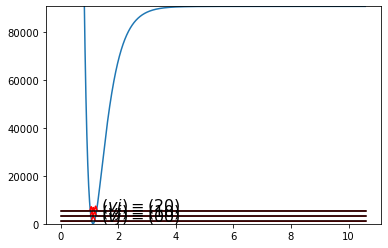

In [29]:
# by default, display j=0 on the top of the graphe with the potential energy curve
for j in range(1):
    plot(r*au_A,diag(V[:,:,1])*Ryd)
    for v in range(vmax_to_print-1):
        Delta=(E[v+1,j]-E[v,j]-0.05*(E[v+1,j]-E[v,j]))*219474
        maxval=(abs(psi[:,v,j])**2).max()
        plot(r*0.53,E[v,j]*Ryd+abs(psi[:,v,j])**2*Delta/maxval,'-r')  
        plot(r*0.53,Eplot[:,v,j]*Ryd,'-k')
       # plt.arrow(1.6, E_CO[v]*Ryd, 0.,(E_CO[v+1]-E_CO[v])*Ryd*0.9 , head_width=0.01, head_length=0.01, fc='g', ec='g')
        #annotate('$\hbar \omega$', xy=(1.6,(E_CO[v]+E_CO[v+1])*Ryd/2.),xytext=(1.6,(E_CO[v]+E_CO[v+1])*Ryd/2.),xycoords='data',size=16)
        annotate('$(vj)=($'+str(v)+str(j)+')', xy=(1.4,(E[v,j]+0.03*E[v,j])*Ryd),xytext=(1.4,(E[v,j]+0.03*E[v,j])*Ryd),xycoords='data',size=16)
        ylim(V[:,:,j].min(),V[Nr-1,Nr-1,j]*Ryd)
        #xlim(0.9,1.7)

### Wave functions, $\psi_{vjm}(r,\theta,\phi)$

E_${v j}$  0 0
E_${v j}$  0 1
E_${v j}$  0 2
E_${v j}$  0 3
E_${v j}$  0 4
E_${v j}$  0 5
E_${v j}$  0 6
E_${v j}$  0 7
E_${v j}$  0 8
E_${v j}$  0 9
E_${v j}$  0 10
E_${v j}$  0 11
E_${v j}$  0 12
E_${v j}$  0 13
E_${v j}$  0 14
E_${v j}$  1 0
E_${v j}$  1 1
E_${v j}$  1 2
E_${v j}$  1 3
E_${v j}$  1 4
E_${v j}$  1 5
E_${v j}$  1 6
E_${v j}$  1 7
E_${v j}$  1 8
E_${v j}$  1 9
E_${v j}$  1 10
E_${v j}$  1 11
E_${v j}$  1 12
E_${v j}$  1 13
E_${v j}$  1 14
E_${v j}$  2 0
E_${v j}$  2 1
E_${v j}$  2 2
E_${v j}$  2 3
E_${v j}$  2 4
E_${v j}$  2 5
E_${v j}$  2 6
E_${v j}$  2 7
E_${v j}$  2 8
E_${v j}$  2 9
E_${v j}$  2 10
E_${v j}$  2 11
E_${v j}$  2 12
E_${v j}$  2 13
E_${v j}$  2 14
E_${v j}$  3 0
E_${v j}$  3 1
E_${v j}$  3 2
E_${v j}$  3 3
E_${v j}$  3 4
E_${v j}$  3 5
E_${v j}$  3 6
E_${v j}$  3 7
E_${v j}$  3 8
E_${v j}$  3 9
E_${v j}$  3 10
E_${v j}$  3 11
E_${v j}$  3 12
E_${v j}$  3 13
E_${v j}$  3 14


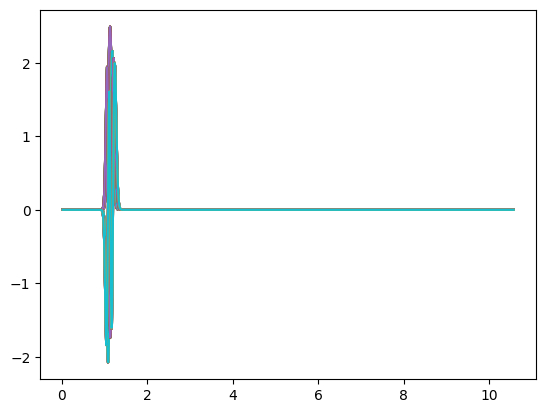

In [3]:
# to be selected in the menu by the user
for v in range(vmax_to_print):
    for j in range(jmax_to_print):
        plot(r*au_A,psi[:,v,j])
        print("E_${v j}$ ",v,j)
       # $E_{vj}$

## Observables

### Rotational constantes

$B_v=\int dr u_{v,0}^*(r)\left(\frac{\hbar^2}{2\mu r^2}\right)u_{v,0}(r)$

([<matplotlib.axis.XTick at 0x742069574d00>,
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

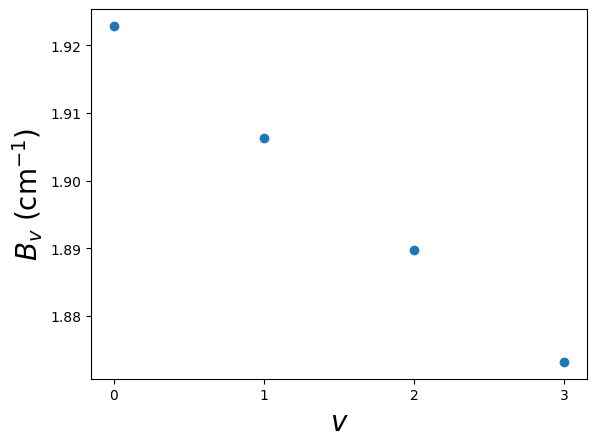

In [4]:
Bv=numpy.zeros(Nr,float)
v_plot=numpy.zeros(Nr,int)
for v in range(vmax_to_print): 
    v_plot[v]=v
    for i in range(Nr):
        Bv[v]=Bv[v]+delta_r*(1./(2*mu*r[i]**2))*psi[i,v,0]**2
        
    #print('Bv',Bv[v]*Ryd,'1/cm','for v=',v)
    
plot(v_plot[0:vmax_to_print],Bv[0:vmax_to_print]*Ryd,'o')
xlabel("$v$",size=20)
ylabel("$B_v$ (cm$^{-1}$)",size=20)
xticks(v_plot[0:vmax_to_print], v_plot[0:vmax_to_print], rotation=0)

### Energy spectrum

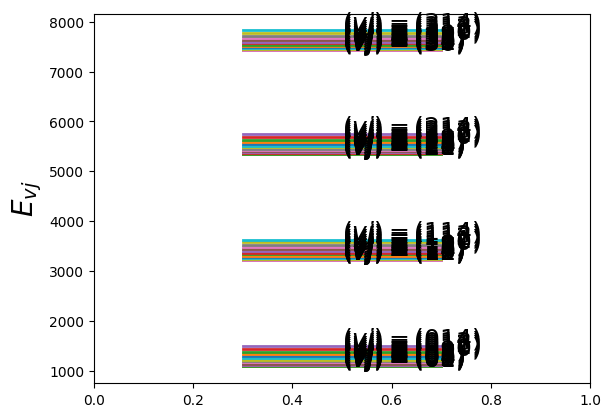

In [5]:
E_plot=numpy.zeros(10,float)
E_rot_plot=numpy.zeros(10,float)
x_plot=linspace(0.3,0.7,10)
for  v in range(vmax_to_print):
    #figure(v)
    for j in range(jmax_to_print):
        E_rot_plot[:]=E[v,j]
        plot(x_plot,E_rot_plot*Ryd,lw=2)
        
        annotate('$(vj)=('+str(v)+str(j)+')$', xy=(0.5,E[v,j]*Ryd),xytext=(0.5,E[v,j]*Ryd),xycoords='data',size=18)
    xlim(0,1)
    #ylabel("$E_{"+str(v)+"j}$",size=20)
    ylabel("$E_{vj}$",size=20)

Text(0.5, 0, '$v$')

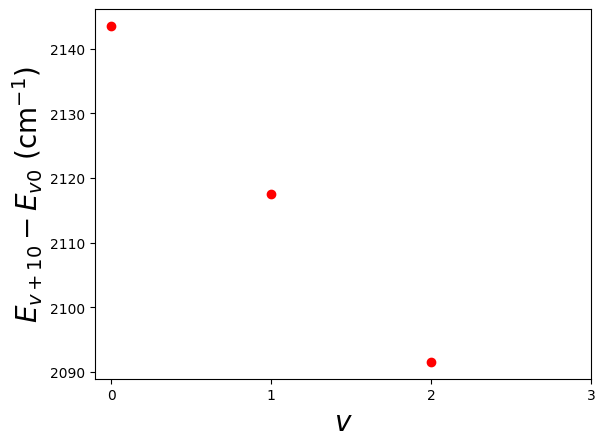

In [6]:
j=0 # fixed
Delta_Ev=numpy.zeros(vmax_to_print,float)
for  v in range(vmax_to_print-1):
    Delta_Ev[v]=E[v+1,j]-E[v,j]
plot(v_plot[0:vmax_to_print-1],Delta_Ev[0:vmax_to_print-1]*Ryd,'or',lw=2)
xticks(v_plot[0:vmax_to_print], v_plot[0:vmax_to_print], rotation=0)
ylabel("$E_{v+1 "+str(0)+"}-E_{v "+str(0)+"}$ (cm$^{-1})$",size=20)
xlabel("$v$",size=20)

Text(0.5, 0, '$j$')

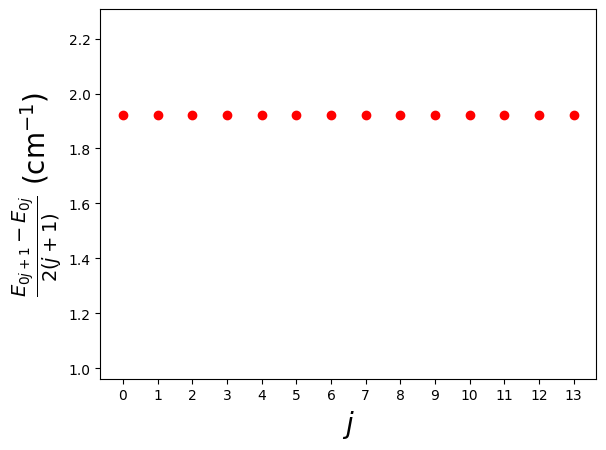

In [7]:
v=0
Delta_Ej=numpy.zeros(jmax_to_print-1,float)
j_plot=numpy.zeros(jmax_to_print-1,int)
for  j in range(jmax_to_print-1):
    Delta_Ej[j]=E[v,j+1]-E[v,j]
    j_plot[j]=j
    Delta_Ej[j]=Delta_Ej[j]/(2*(j+1))
    #print(Delta_Ej[j]*Ryd/(2*(j+1)))
plot(j_plot[0:jmax_to_print-1],Delta_Ej[0:jmax_to_print-1]*Ryd,'or',lw=2)
xticks(j_plot[0:jmax_to_print], j_plot[0:jmax_to_print], rotation=0)
ylim(max(Delta_Ej*Ryd)/2.,max(Delta_Ej*Ryd)+0.2*max(Delta_Ej*Ryd))
ylabel("$\\frac{E_{"+str(v)+" j+1}-E_{"+str(v)+" j}}{2(j+1)}$ (cm$^{-1})$",size=20)
xlabel("$j$",size=20)

In [8]:
v=0
# we will see later if we add this in the interface
print("P branche")
print("j jp jp-j  Delta E_{0jp,1j} in 1/cm")
for j in range(jmax-1):
    for jp in range(jmax-1):
        if(j!=jp and jp-j==1):
            print(j,jp,(E[v+1,jp]-E[v,j])*Ryd)

P branche
j jp jp-j  Delta E_{0jp,1j} in 1/cm
0 1 2147.3551107081985
1 2 2151.1346665634583
2 3 2154.8809482543443
3 4 2158.593807889776
4 5 2162.273097296987
5 6 2165.918668026606
6 7 2169.5303713584517
7 8 2173.1080583054954
8 9 2176.6515796193667
9 10 2180.160785795023
10 11 2183.6355270756217
11 12 2187.075653456531
12 13 2190.481014689977
13 14 2193.851460289467
14 15 2197.186839534119
15 16 2200.4870014719418
16 17 2203.7517949244448
17 18 2206.981068490119
18 19 2210.1746705481014
19 20 2213.332449261687
20 21 2216.4542525812053
21 22 2219.5399282480025
22 23 2222.5893237967516
23 24 2225.602286558899
24 25 2228.5786636643415
25 26 2231.51830204575
26 27 2234.4210484391465
27 28 2237.2867493868166


In [9]:
# we will see later if we add this in the interface
v=0
print("R branche")
print("jp j jp-j  Delta E_{0jp,1j} in 1/cm")
for jp in range(jmax-1):
    for j in range(jmax-1):
        if(j!=jp and jp-j==-1):
            print(jp,j,jp-j,(E[v+1,jp]-E[v,j])*Ryd)


R branche
jp j jp-j  Delta E_{0jp,1j} in 1/cm
0 1 -1 2139.6967666283913
1 2 -1 2135.8182727296853
2 3 -1 2131.907093306493
3 4 -1 2127.9633747599337
4 5 -1 2123.987263175944
5 6 -1 2119.978904319747
6 7 -1 2115.9384436295336
7 8 -1 2111.866026210281
8 9 -1 2107.761796827991
9 10 -1 2103.625899903314
10 11 -1 2099.458479504873
11 12 -1 2095.2596793434386
12 13 -1 2091.0296427650187
13 14 -1 2086.7685127443337
14 15 -1 2082.476431878477
15 16 -1 2078.1535423798746
16 17 -1 2073.7999860693435
17 18 -1 2069.4159043700633
18 19 -1 2065.0014382998083
19 20 -1 2060.556728463962
20 21 -1 2056.081915049307
21 22 -1 2051.5771378158997
22 23 -1 2047.0425360903162
23 24 -1 2042.4782487583389
24 25 -1 2037.8844142586172
25 26 -1 2033.2611705728068
26 27 -1 2028.6086552204067
27 28 -1 2023.9270052511229


## Selection rules

Dipole moment, $D(r)$

(-0.5, 0.5)

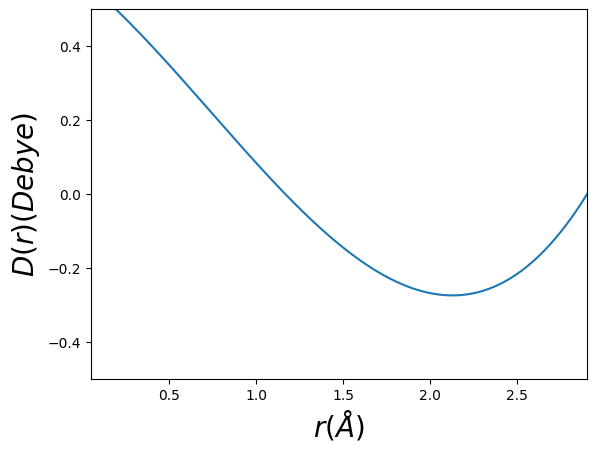

In [10]:
a0=1.47773
a1=-0.517427
a2=-0.146225
a3=0.0349042
I1=numpy.zeros((vmax_to_print,vmax_to_print),float) #here for j=j'=0
x_axis_labels=numpy.zeros(vmax_to_print,int)
y_axis_labels=numpy.zeros(vmax_to_print,int)
D=numpy.zeros(Nr,float)
for vp in range(vmax_to_print):
    y_axis_labels[vp]=vp#round(E[vp,0]*Ryd)
    for v in range(vmax_to_print):
        x_axis_labels[v]=v #round(E[v,0]*Ryd)
        for i in range(Nr):
            D[i]=a0+a1*r[i]+a2*r[i]**2+a3*r[i]**3 #r[i]-re #
            #if(v!=vp):
            I1[vp,v]=I1[vp,v]+psi[i,vp,0]*D[i]*psi[i,v,0]*delta_r
        #print(vp,E[vp,0]*Ryd,v,E[v,0]*Ryd,I1[vp,v])
plot(r*au_A,D*au_debye)
xlabel("$r(\\AA)$",size=20)
ylabel("$D(r) (Debye)$",size=20)
xlim(rmin,2.9)
ylim(-0.5,0.5)

$\mathcal{I}_{v'j',vj}=\int dru^*_{v'j'}(r)D(r)u_{vj}(r)\simeq \int dru^*_{v'0}(r)D(r)u_{v0}(r) $

[Text(0.5, 23.52222222222222, '$(vj)=(v0)$'),
 Text(50.722222222222214, 0.5, "$(v'j')=(v'0)$")]

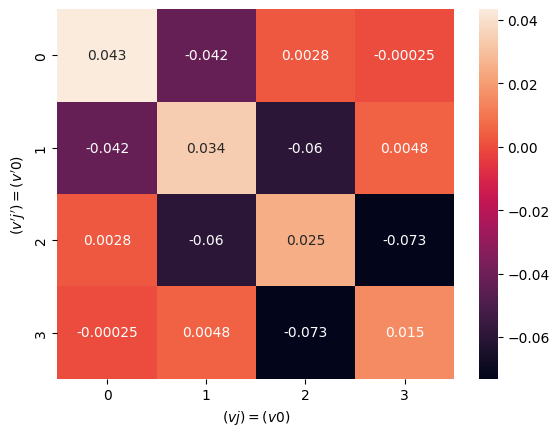

In [11]:
import seaborn
s= seaborn.heatmap(I1[0:vmax_to_print,0:vmax_to_print],annot=True, xticklabels=x_axis_labels, yticklabels=y_axis_labels)
s.set(xlabel="$(vj)=(v0)$", ylabel="$(v'j')=(v'0)$")

$\mathcal{I}_{j'm',jm}=\iint \sin\theta d\theta d\phi \left[\mathcal{Y}_{j'}^{m'}(\theta,\phi)\right]^*\cos\theta\;\mathcal{Y}_j^m(\theta,\phi)$. Using the expression, $\cos\theta=2\sqrt{\frac{\pi}{3}}\mathcal{Y}_1^0(\theta,\phi)$ and the property of the spherical harmonics $\left[\mathcal{Y}_j^m(\theta,\phi)\right]^*=(-1)^m\mathcal{Y}_j^{-m}(\theta,\phi)$ , the preceding integral writes as follows
$\mathcal{I}_{j'm',jm}=(-1)^m(-1)^{m'}2\sqrt{\frac{\pi}{3}}\int_{0}^{\pi}\int_{0}^{2\pi} \sin\theta d\theta d\phi \left[\mathcal{Y}_j^{-m}(\theta,\phi)\right]^*\left[\mathcal{Y}_1^0(\theta,\phi)\right]^*\mathcal{Y}_{j'}^{-m'}(\theta,\phi)$, yielding to

$\mathcal{I}_{j'm',jm}=2\sqrt{\frac{\pi}{3}}\sqrt{\frac{(2j+1)(2\times 1+1)}{4\pi(2j'+1)}}C_{j010}^{j'0}C_{jm10}^{j'm'}$, where $C_{j_1m_1j_2m_2}^{j_3m_3}=\left\langle j_1m_1j_2m_2\right|j_3m_3\left.\right\rangle$ are the Clebsch Gordan coefficients (real coefficents).

In [12]:
# in development 
import numpy
from sympy.physics.wigner import clebsch_gordan
I2=numpy.zeros((jmax,jmax,2*jmax+1,2*jmax+1),float) #here I(j',j,m',m)
I2_plot=numpy.zeros((jmax,jmax,2*jmax+1,2*jmax+1),float) #here I(j',j,m',m)
I2_plot=1./I2_plot
x_axis_labels=numpy.zeros(jmax,int)#float)
y_axis_labels=numpy.zeros(jmax,int)#float)
v=0
vp=1
m_plot=0
mp_plot=0

for jp in range(jmax):
    y_axis_labels[jp]=jp#round(E[vp,jp]*Ryd)
    
    for mp in range(-jp,jp+1):    
        for j in range(jmax):
            x_axis_labels[j]=j#round(E[v,j]*Ryd)

            for m in range(-j,j+1): 
                #I2[jp,j,imp,im]=clebsch_gordan(j, 1, jp, m_plot, 0, mp_plot)*2*sqrt(pi/3) # l 1 l' m 0 m'
                #print('imp=',imp,jp,mp,'im=',im,j,m)
                C1=clebsch_gordan( j, 1, jp, 0, 0, 0)#j1,j2,j3,m1,m2,m3
                C2=clebsch_gordan( j, 1, jp, m, 0, mp)
                A=sqrt(3*(2*j+1)/(4*pi*(2*jp+1)))
                I2[jp,j,mp,m]=A*2*sqrt(pi/3)*C1*C2
                I2_plot[jp,j,mp,m]=I2[jp,j,mp,m]


/tmp/ipykernel_217150/1712448928.py:6: RuntimeWarning: divide by zero encountered in divide
  I2_plot=1./I2_plot


$\mathcal{I}_{j'0,j0}$


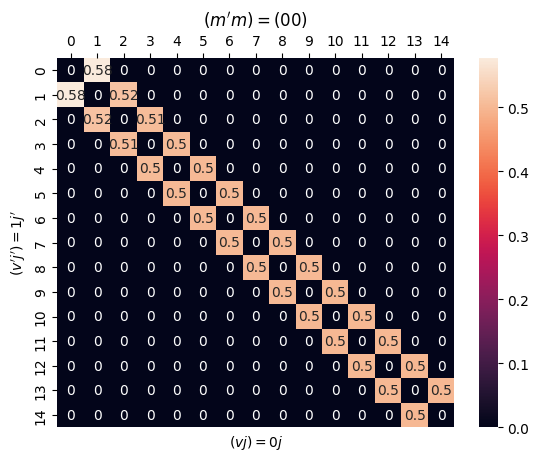

<Figure size 640x480 with 0 Axes>

In [13]:
ifig=0
mp=0
m=0
print("$\mathcal{I}_{j'"+str(mp)+",j"+str(m)+"}$")
for imp in range(-jmax_to_print+1,jmax_to_print): 
    for im in range(-jmax_to_print+1,jmax_to_print):
        figure(ifig)
        if(imp==mp and im==m):
            #print(abs(mp),abs(m),jmax_to_print-1)
            s= seaborn.heatmap(I2_plot[0:jmax_to_print,0:jmax_to_print,imp,im],annot=True, xticklabels=x_axis_labels[0:jmax_to_print], yticklabels=y_axis_labels[0:jmax_to_print],)
            s.set(xlabel="$(vj)="+str(v)+"j$", ylabel="$(v'j')="+str(vp)+"j'$")
            s.set(title="$(m'm)=("+str(imp)+str(im)+")$")
            s.xaxis.tick_top() # x axis on top
            ifig=ifig+1


$\mathcal{R}_{1j+1\leftarrow 0j }=\sum_{m=-j}^j(2j+1)e^{-E_{vj}/k_bT}C\left|\left\langle \Psi_{1j+1m}\left|\hat{D}(r)\cos\theta\right|\Psi_{0jm}\right\rangle\right|^2$, where $C=\frac{\pi\nu_{1j+1\leftarrow 0j}}{3\epsilon_0c\hbar}$



In [14]:
kT=300.  # in Kelvin to be chosen by the user 
v=0      # to be chosen by the user
vp=1     # to be chosen by the user

au_K=3.1577465e5
kT=kT/au_K

Intensity=numpy.zeros((jmax,jmax),float)
for j in range(jmax):
    for m in range(-j,j+1):
        for jp in range(jmax):
#            for mp in range(-jp,jp+1):
            Intensity[jp,j]=Intensity[jp,j]+abs(I2[jp,j,m,m]*I1[vp,v])**2
    Intensity[:,j]=Intensity[:,j]/(2*j+1)

In [15]:
R=numpy.zeros(jmax,float)
Delta_R=numpy.zeros(jmax,float)

iplot_R=0
c=137.
epsilon0=1./(4*pi) #4*pi*epsilon0=1

    
for j in range(jmax):
    for jp in range(jmax):
        if(jp-j==1):
            Delta_R[iplot_R]=E[vp,jp]-E[v,j]
            nu=Delta_R[iplot_R]/(2*pi) # h=2pi
            C=pi*nu/(3*epsilon0*c)
            R[iplot_R]=Intensity[jp,j]*C*(2*j+1)*exp(-E[v,j]/kT)#((2*j+1)*exp(-E[v,j]/kT)-(2*jp+1)*exp(-E[vp,jp]/kT))/Q#*(2*j+1)/(2*jp+1)
            iplot_R=iplot_R+1
            
#plot(Delta_R[0:iplot_R]*Ryd,R[0:iplot_R],'o')
#plt.gca().invert_xaxis()

$\mathcal{P}_{1j-1\leftarrow 0j }=\sum_{m=-j}^j(2j+1)e^{-E_{vj}/k_bT}C\left|\left\langle \Psi_{1j-1m}\left|\hat{D}(r)\cos\theta\right|\Psi_{0jm}\right\rangle\right|^2$, where $C=\frac{\pi\nu_{1j-1\leftarrow 0j}}{3\epsilon_0c\hbar}$

In [16]:
P=numpy.zeros(jmax,float)
Delta_P=numpy.zeros(jmax,float)

iplot_P=0
c=137.
epsilon0=1./(4*pi) #4*pi*epsilon0=1

for j in range(jmax):
    for jp in range(jmax):
        if(j-jp==1):
            Delta_P[iplot_P]=E[vp,jp]-E[v,j]
            nu=Delta_P[iplot_P]/(2*pi) # h=2pi
            C=pi*nu/(3*epsilon0*c)
            P[iplot_P]=Intensity[jp,j]*C*(2*j+1)*exp(-E[v,j]/kT)
            #abs(I2[jp,j,mp,m]*I1[vp,v])**2*(2*j+1)*exp(-E[v,j]/kT)#*C*((2*j+1)*exp(-E[v,j]/kT)-(2*jp+1)*exp(-E[vp,jp]/kT))/Q#*(2*jp+1)/(2*j+1)
            iplot_P=iplot_P+1
            
#plot(Delta_P[0:iplot_P]*Ryd,P[0:iplot_P],'o')
#plt.gca().invert_xaxis()

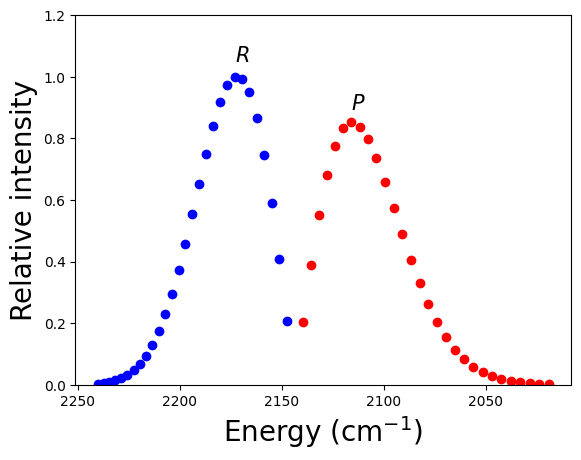

In [17]:
max_P_R=max(max(R[0:iplot_R]),max(P[0:iplot_P]))
plot(Delta_R[0:iplot_R]*Ryd,R[0:iplot_R]/max_P_R,'ob')
plot(Delta_P[0:iplot_P]*Ryd,P[0:iplot_P]/max_P_R,'or')
maxloc_R=argmax(R[0:iplot_R]/max_P_R);maxloc_P=argmax(P[0:iplot_P]/max_P_R)
x_R=Delta_R[maxloc_R]*Ryd;y_R=R[maxloc_R]/max_P_R+0.05*R[maxloc_R]/max_P_R
x_P=Delta_P[maxloc_P]*Ryd;y_P=P[maxloc_P]/max_P_R+0.05*P[maxloc_P]/max_P_R
annotate('$R$', xy=(x_R,y_R),xytext=(x_R,y_R),xycoords='data',size=15)
annotate('$P$', xy=(x_P,y_P),xytext=(x_P,y_P),xycoords='data',size=15)
xlabel("Energy (cm$^{-1}$)",size=20)
ylabel("Relative intensity",size=20)
ylim(0,1.2)
plt.gca().invert_xaxis()

In [18]:
# convolution
Ne=500000
Energy=numpy.zeros(Ne,float)
Energy=numpy.linspace(min(Delta_P[0:iplot_P])+20/Ryd,max(Delta_R[0:iplot_R]),Ne)
Convoluted_Intensity=numpy.zeros(Ne,float)
c=137.
h=2*pi
M=m1+m2
M=M/au_amu
A=sqrt(M/(2*pi*kT))
print('T=',kT*au_K,'K ','M=',M*au_amu,'amu' )
delta_Energy=Energy[1]-Energy[0]
print(Energy[0]*Ryd,'-->',Energy[Ne-1]*Ryd,'with a step of',delta_Energy*Ryd,' 1/cm')

for ie in range(Ne):
    nu=Energy[ie]/h
    #print(ie,nu)
    for iplot in range(iplot_R):
        nu0=Delta_R[iplot]/h
        Convoluted_Intensity[ie]=Convoluted_Intensity[ie]+c/nu0*A*R[iplot]*exp(-M*(c*(nu/nu0-1))**2/(2*kT))*delta_Energy
        #print(ie,nu,nu0,iplot,M*(c*(nu/nu0-1))**2,exp(-M*(c*(nu/nu0-1))**2/(2*kT))*delta_Energy)
        
    for iplot in range(iplot_P):
        nu0=Delta_P[iplot]/h
        Convoluted_Intensity[ie]=Convoluted_Intensity[ie]+c/nu0*A*P[iplot]*exp(-M*(c*(nu/nu0-1))**2/(2*kT))*delta_Energy

T= 300.0 K  M= 27.999000000000002 amu
2039.216357235778 --> 2240.115251239881 with a step of 0.00040179859160247386  1/cm


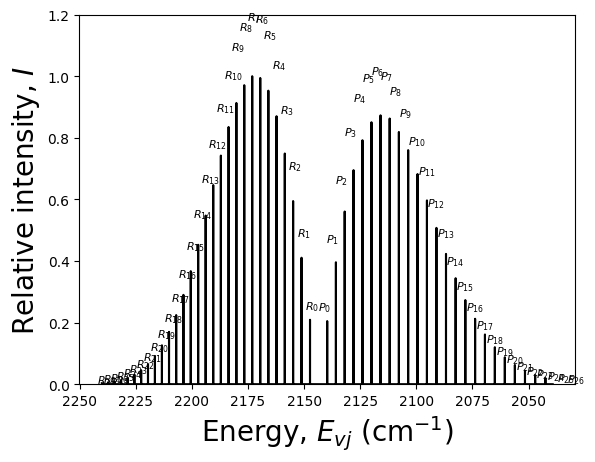

In [19]:
plt.plot(Energy*Ryd,Convoluted_Intensity/max(Convoluted_Intensity),'k')
plt.xlabel("Energy, $E_{vj}$ (cm$^{-1}$)",size=20)
plt.ylabel("Relative intensity, $I$",size=20)
for iplot in range(iplot_R):
    y=R[iplot]/max(Convoluted_Intensity)+R[iplot]/max(Convoluted_Intensity)*0.1
    x=Delta_R[iplot]*Ryd
    y=y/2.
    x=x+x*0.001
    annotate('$R_{'+str(iplot)+'}$', xy=(x,y),xytext=(x,y),xycoords='data',size=8)
    
for iplot in range(iplot_P):
    y=P[iplot]/max(Convoluted_Intensity)+P[iplot]/max(Convoluted_Intensity)*0.1
    x=Delta_P[iplot]*Ryd
    y=y/2.
    x=x+x*0.002
    annotate('$P_{'+str(iplot)+'}$', xy=(x,y),xytext=(x,y),xycoords='data',size=8)
ylim(0,1.2)
plt.gca().invert_xaxis()

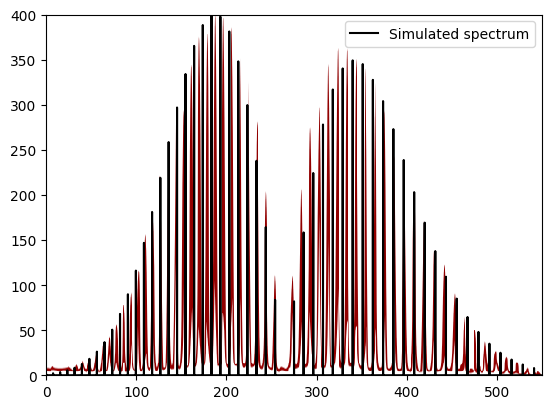

In [21]:
Reverse_Convoluted_Intensity=np.zeros(Ne,float)
Energy_plot=np.zeros(Ne,float)
im = plt.imread("Carbon_monoxide_IR_rotational-vibrational_spectrum_v2.png")
#x=range(300)
#plt.plot(x,x)
IntSacale=(550-0)
Energy_plot=(Energy-min(Energy))/(max(Energy)-min(Energy))*IntSacale
for ie in range(Ne):
    Reverse_Convoluted_Intensity[ie]=Convoluted_Intensity[Ne-1-ie]
    
plt.plot(Energy_plot,Reverse_Convoluted_Intensity*400/max(Reverse_Convoluted_Intensity),'k')
plt.imshow(im,origin='upper',cmap ="binary_r", interpolation ='nearest',extent=[0,550,0,400])
legend(["Simulated spectrum"])
plt.show()

#2040 --> 2240

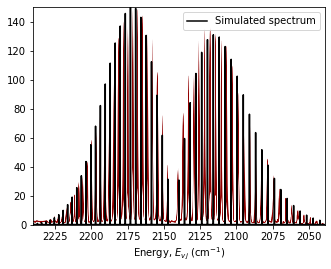

In [34]:
im = plt.imread("Carbon_monoxide_IR_rotational-vibrational_spectrum_v2.png")
plt.plot(Energy*Ryd,Convoluted_Intensity*150/max(Convoluted_Intensity),'k')
plt.imshow(im,origin='upper',cmap ="binary_r", interpolation ='nearest',extent=[max(Energy)*Ryd,min(Energy)*Ryd,0,150])
xlabel("Energy, $E_{vj}$ (cm$^{-1}$)")
legend(["Simulated spectrum"])
plt.show()